In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost
from xgboost import plot_tree, to_graphviz
import holidays as hdays


df = pd.read_excel('caffe_change.xlsx')

In [55]:
holidays = hdays.IN()
df['Is_holiday'] = df['Date'].apply(lambda x: 1 if x in holidays else 0)

In [56]:
df['Date'] = pd.to_datetime(df['Date'])

daily = (df.groupby('Date')
                   .agg({
                       'Quantity': 'sum',
                       'Total': 'sum',
                       'Week day': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units', 'Total': 'Total_Sales'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Week day"] = daily["Week day"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
daily["Month"] = daily["Date"].dt.month
daily["Year"] = daily["Date"].dt.year

daily.head(400)

,Date,Total_Units,Total_Sales,Week day,Week number,Day,Month,Year
0,2010-04-01,434,77066.51,3,13,1,4,2010
1,2010-04-02,489,88423.17,4,13,2,4,2010
2,2010-04-03,766,140314.76,5,13,3,4,2010
3,2010-04-04,467,86284.74,6,13,4,4,2010
4,2010-04-05,385,75674.14,0,14,5,4,2010
...,...,...,...,...,...,...,...,...
360,2011-03-27,441,90777.48,6,12,27,3,2011
361,2011-03-28,401,86109.16,0,13,28,3,2011
362,2011-03-29,448,88549.27,1,13,29,3,2011
363,2011-03-30,707,141621.87,2,13,30,3,2011


In [57]:
X_data, Y_data = daily.drop(columns=["Total_Units", "Date"]), daily["Total_Units"]

In [58]:
x_train, x_test = X_data[:300], X_data[300:]
y_train, y_test = Y_data[:300], Y_data[300:]

In [59]:
xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))

XGBoost Model Performance:
R^2 Score: 0.6945739388465881
Mean Absolute Error: 35.2371826171875
Mean Squared Error: 2282.902099609375


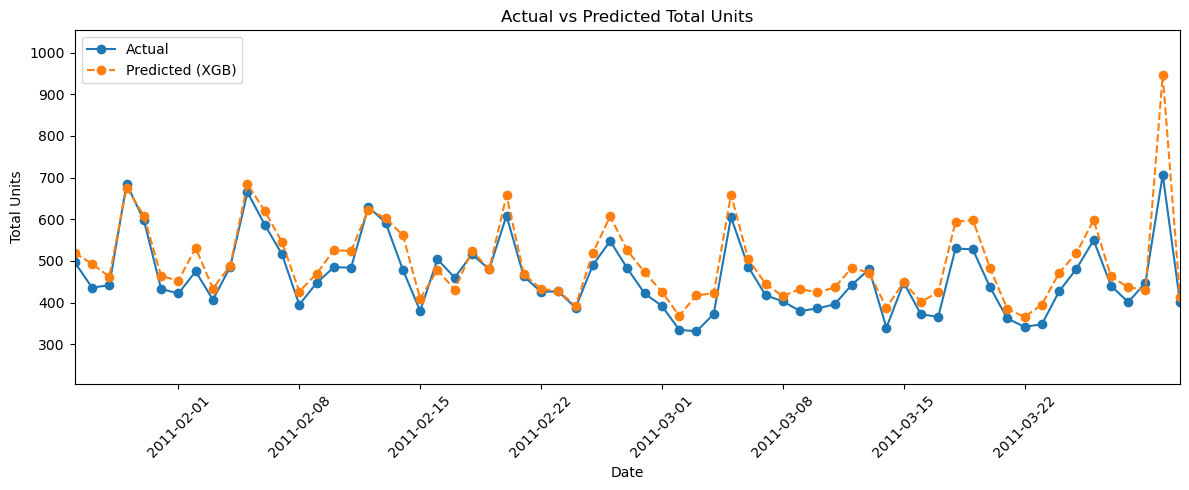

In [60]:
# plot actual vs predicted for the test set
dates = daily['Date'].iloc[300:]  # test dates
plt.figure(figsize=(12,5))
plt.plot(daily["Date"], daily["Total_Units"], label='Actual', marker='o', linestyle='-')
plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Units')
plt.title('Actual vs Predicted Total Units')
plt.legend()
plt.xlim(dates.min(), dates.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
daily = (df.groupby(['Date', 'Category'], )
                   .agg({
                       'Quantity': 'sum',
                       'Total': 'sum',
                       'Week day': 'first',
                       'Week number': 'first',
                    #    'Is_holiday': 'max'
                   })
                   .reset_index()
                   .rename(columns={'Quantity': 'Total_Units', 'Total': 'Total_Sales'})
)

daily.sort_values(by='Date', inplace=True)

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = daily["Week day"].unique()

sorted_days = sorted(days, key=lambda d: week_order.index(d))

weekday_dict = {}
for x in range(len(sorted_days)):
    weekday_dict[sorted_days[x]] = x

daily["Week day"] = daily["Week day"].map(weekday_dict)

daily["Day"] = daily["Date"].dt.day
daily["Month"] = daily["Date"].dt.month
daily["Year"] = daily["Date"].dt.year

daily.head(20)

,Date,Category,Total_Units,Total_Sales,Week day,Week number,Day,Month,Year
0,2010-04-01,ADD-ONS,8,185.62,3,13,1,4,2010
1,2010-04-01,BEVERAGE,137,13451.81,3,13,1,4,2010
2,2010-04-01,FOOD,175,27751.13,3,13,1,4,2010
3,2010-04-01,LIQUOR,29,4026.75,3,13,1,4,2010
4,2010-04-01,MERCHANDISE,3,387.00,3,13,1,4,2010
5,2010-04-01,TOBACCO,82,31264.20,3,13,1,4,2010
6,2010-04-02,ADD-ONS,8,290.81,4,13,2,4,2010
7,2010-04-02,BEVERAGE,174,16805.45,4,13,2,4,2010
8,2010-04-02,FOOD,178,29854.91,4,13,2,4,2010
9,2010-04-02,LIQUOR,46,10647.00,4,13,2,4,2010


Category: ADD-ONS
XGBoost Model Performance:
R^2 Score: 0.22344273328781128
Mean Absolute Error: 1.1571201086044312
Mean Squared Error: 2.6408748626708984




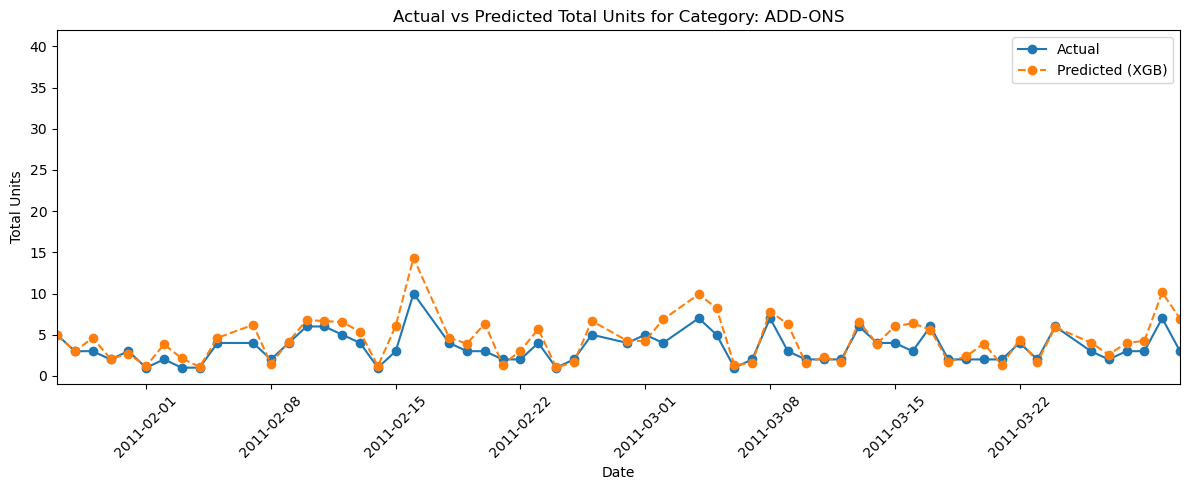

Category: BEVERAGE
XGBoost Model Performance:
R^2 Score: 0.9347609877586365
Mean Absolute Error: 6.585911273956299
Mean Squared Error: 76.94306945800781




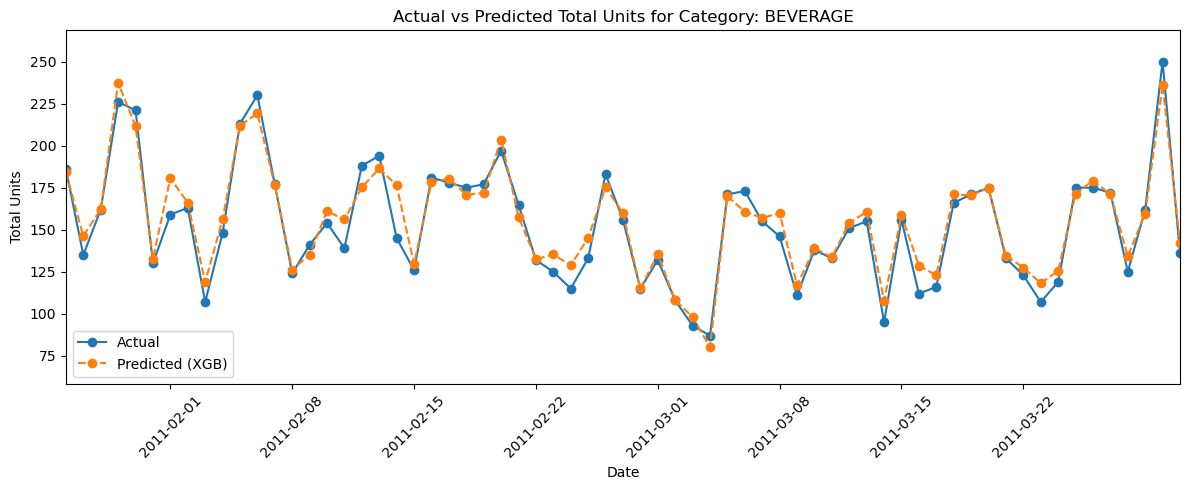

Category: FOOD
XGBoost Model Performance:
R^2 Score: 0.9027742743492126
Mean Absolute Error: 6.8790483474731445
Mean Squared Error: 127.13569641113281




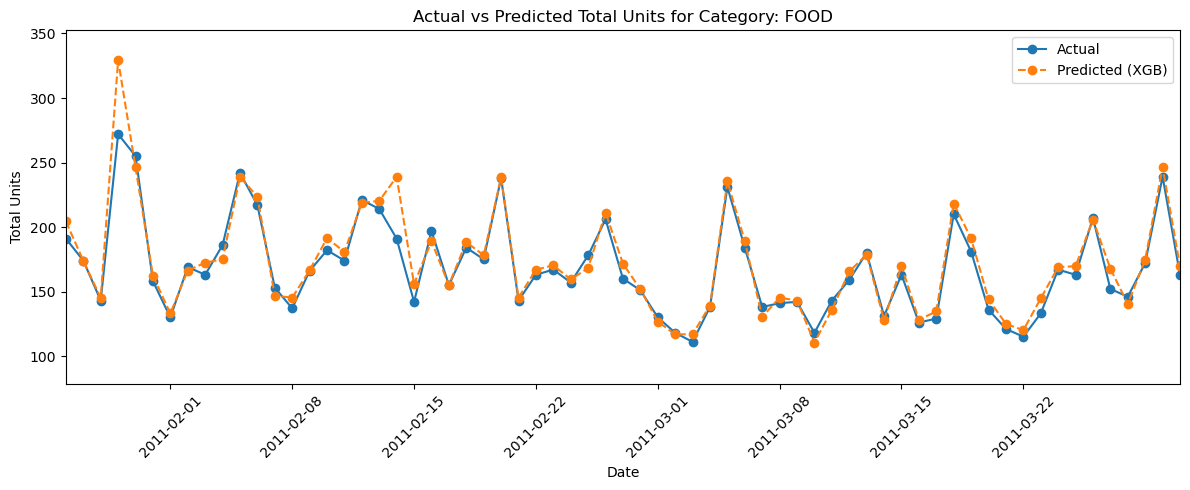

Category: LIQUOR
XGBoost Model Performance:
R^2 Score: 0.5642138719558716
Mean Absolute Error: 8.75168514251709
Mean Squared Error: 195.8147735595703




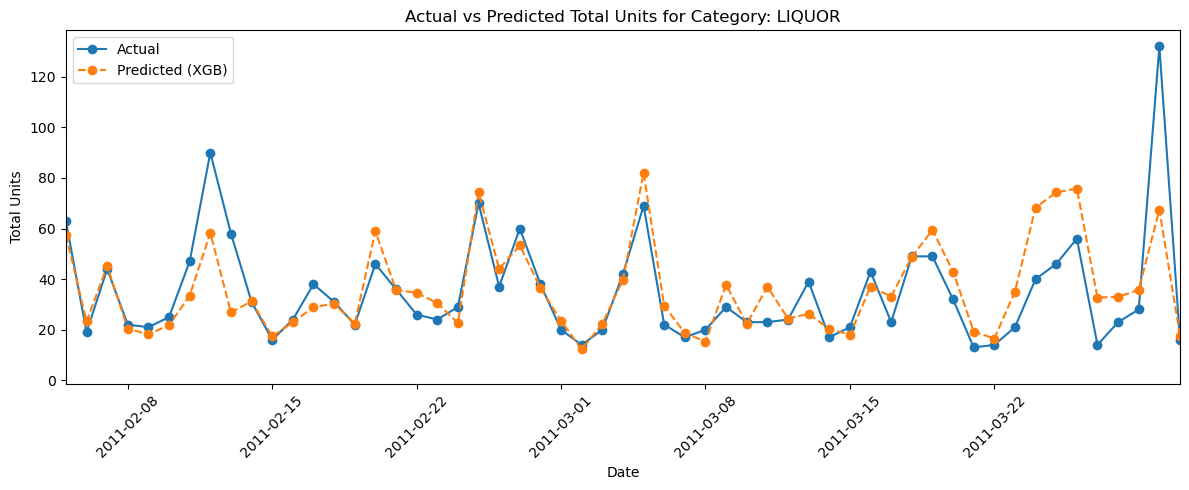

Category: TOBACCO
XGBoost Model Performance:
R^2 Score: 0.2994574308395386
Mean Absolute Error: 9.68233585357666
Mean Squared Error: 139.20916748046875




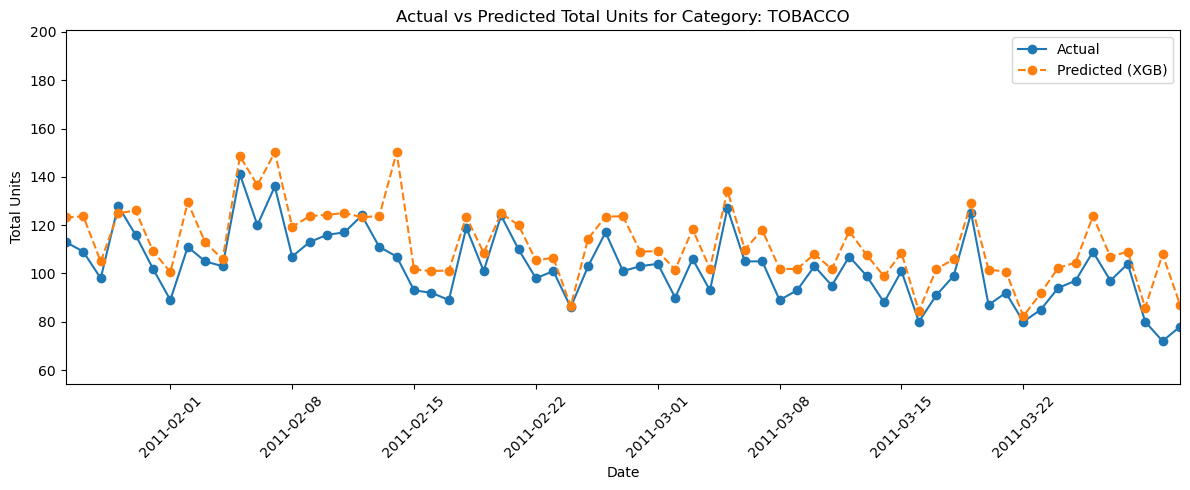

In [62]:
for category, df_cat in daily.groupby('Category'):
    if category == "LIQUOR " or category == "LIQUOR & TPBACCO" or category == "MERCHANDISE" or category == "MISC":
        continue

    print(f"Category: {category}")
    # print(df_cat.head())
    
    X_data, Y_data = df_cat.drop(columns=["Total_Units", "Date", "Category"]), df_cat["Total_Units"]

    x_train, x_test = X_data[:300], X_data[300:]
    y_train, y_test = Y_data[:300], Y_data[300:]

    xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
    xgb.fit(x_train, y_train)
    y_pred_xgb = xgb.predict(x_test)

    print("XGBoost Model Performance:")
    print("R^2 Score:", r2_score(y_test, y_pred_xgb))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
    print("\n")
    # plot actual vs predicted for the test set
    dates = df_cat['Date'].iloc[300:]  # test dates
    plt.figure(figsize=(12,5))
    plt.plot(df_cat["Date"], df_cat["Total_Units"], label='Actual', marker='o', linestyle='-')
    plt.plot(dates, y_pred_xgb, label='Predicted (XGB)', marker='o', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Total Units')
    plt.title(f'Actual vs Predicted Total Units for Category: {category}')
    plt.legend()
    plt.xlim(dates.min(), dates.max())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
